In [8]:
pip install scikit-bio

In [9]:
# ============================
# DIAGNOSE — check what samples
# are actually in the depth file
# ============================
print(f"Raw depth file shape: {raw_d.shape}")
print(f"\nRow 0 (first 10 cols):")
print(raw_d.iloc[0, :10].tolist())
print(f"\nRow 1 (first 10 cols):")
print(raw_d.iloc[1, :10].tolist())

print(f"\nAll columns in depth file:")
for i, c in enumerate(df_d.columns):
    print(f"  {i}: {c}")

print(f"\nSample cols identified:")
print(sample_cols_d)

print(f"\ndepth_map keys:")
print(list(depth_map.keys()))

print(f"\nMatches found:")
for s in sample_cols_d:
    match = s in depth_map
    print(f"  {s:<20} in depth_map: {match}")

Raw depth file shape: (5894, 8)

Row 0 (first 10 cols):
['ANATOMY', nan, nan, nan, nan, nan, nan, nan]

Row 1 (first 10 cols):
['Zotu', 'Domain', 'Phylum', 'Class', 'Order', 'Family', 'Genus', 'Species']

All columns in depth file:
  0: Zotu
  1: Domain
  2: Phylum
  3: Class
  4: Order
  5: Family
  6: Genus
  7: Species

Sample cols identified:
[]

depth_map keys:
['IX.10CM.A', 'IX.20CM.B', 'IX.30CM.A', 'IX.40CM.A', 'IX.50CM.A', 'IX.60CM.A', 'IX.70CM.A', 'IX.80CM.A']

Matches found:


Depth profile ZOTUs: 5892
Depth profile samples: ['MF.28A', 'MF.31B', 'IX.10CM.A', 'IX.20CM.B', 'IX.30CM.A', 'IX.40CM.A', 'IX.50CM.A', 'IX.60CM.A', 'IX.70CM.A', 'IX.80CM.A']

Depth samples found: ['IX.10CM.A', 'IX.20CM.B', 'IX.30CM.A', 'IX.40CM.A', 'IX.50CM.A', 'IX.60CM.A', 'IX.70CM.A', 'IX.80CM.A']

Alpha diversity at depth:
   Sample  Depth_cm  Richness  Shannon  Simpson  Evenness
IX.10CM.A        10      1964 6.157870 0.993603  0.812091
IX.20CM.B        20      1897 6.185124 0.993111  0.819436
IX.30CM.A        30      1666 6.126747 0.994574  0.825910
IX.40CM.A        40      1426 5.733864 0.994528  0.789503
IX.50CM.A        50      1685 6.213572 0.994901  0.836336
IX.60CM.A        60      1825 6.249451 0.995909  0.832224
IX.70CM.A        70      1910 6.054586 0.991781  0.801416
IX.80CM.A        80      1966 6.209662 0.994546  0.818811

SPEARMAN CORRELATION — Diversity vs Depth
  Richness     rho=0.238  p=0.5702  ns
  Shannon      rho=0.238  p=0.5702  ns
  Simpson      rho=0.214  p=0

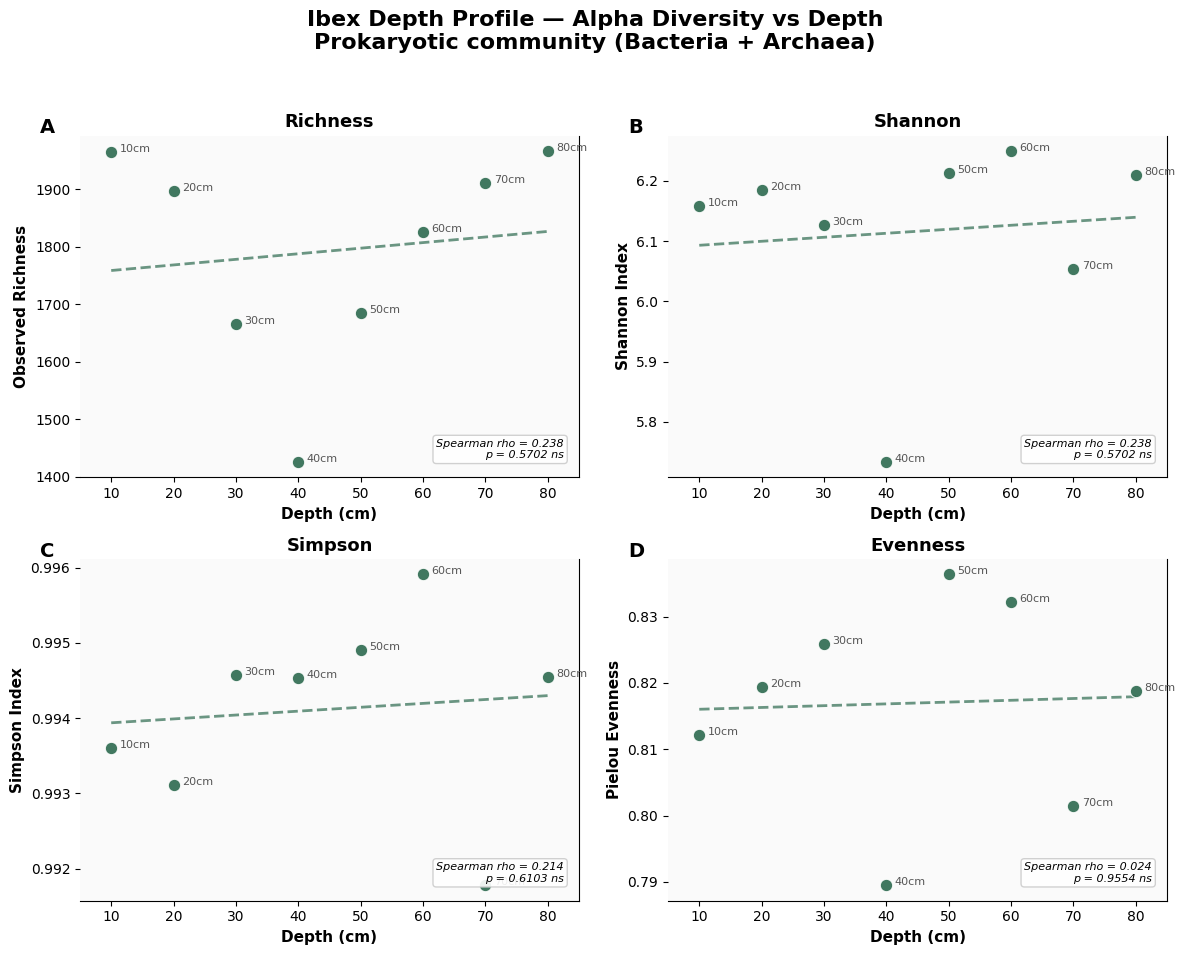

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import spearmanr, linregress
from scipy.spatial.distance import pdist, squareform
from skbio.stats.distance import mantel, DistanceMatrix, permanova

# ============================
# LOAD DEPTH PROFILE FILES
# ============================
depth_count_path  = "/content/zotutab_decontam_Final_Depth_Only.csv"
depth_rel_path    = "/content/zotutab_decontam_RelAbund_Final_Depth_Only.csv"

# count file for alpha diversity
raw_d = pd.read_csv(depth_count_path, header=None)

first_val = str(raw_d.iloc[0, 0]).strip().upper()
if first_val == "ANATOMY":
    header_row_d = 1
    data_start_d = 2
else:
    header_row_d = 0
    data_start_d = 1

df_d = raw_d.iloc[data_start_d:].copy()
df_d.columns = raw_d.iloc[header_row_d].values
df_d.reset_index(drop=True, inplace=True)

tax_cols = ["Domain", "Phylum", "Class", "Order",
            "Family", "Genus", "Species"]
zotu_col_d = df_d.columns[0]

sample_cols_d = [c for c in df_d.columns
                 if c not in tax_cols
                 and c != zotu_col_d
                 and "Blank" not in str(c)]

df_d[sample_cols_d] = df_d[sample_cols_d].apply(
    pd.to_numeric, errors="coerce").fillna(0)

df_d["Domain"] = df_d["Domain"].str.lower().str.strip()
df_d["Phylum"] = df_d["Phylum"].str.lower().str.strip()

micro_d = df_d[
    df_d["Domain"].isin(["bacteria", "archaea"]) &
    (df_d["Phylum"] != "bacteria") &
    df_d["Phylum"].notna()
].copy()

print(f"Depth profile ZOTUs: {len(micro_d)}")
print(f"Depth profile samples: {sample_cols_d}")

# ============================
# DEPTH MAP
# sample name -> depth in cm
# ============================
depth_map = {
    "IX.10CM.A":  10,
    "IX.20CM.B":  20,
    "IX.30CM.A":  30,
    "IX.40CM.A":  40,
    "IX.50CM.A":  50,
    "IX.60CM.A":  60,
    "IX.70CM.A":  70,
    "IX.80CM.A":  80,
}

# keep only samples in depth map
depth_samples = [s for s in sample_cols_d
                 if s in depth_map]
depth_samples.sort(key=lambda s: depth_map[s])

print(f"\nDepth samples found: {depth_samples}")

# ============================
# ALPHA DIVERSITY FUNCTIONS
# ============================
def compute_alpha(counts):
    counts   = counts[counts > 0]
    if len(counts) == 0:
        return 0, 0, 0, 0
    N        = counts.sum()
    p        = counts / N
    shannon  = -np.sum(p * np.log(p))
    simpson  = 1 - np.sum(p ** 2)
    richness = len(counts)
    evenness = shannon / np.log(richness) if richness > 1 else 0
    return shannon, simpson, evenness, richness

# ============================
# COMPUTE ALPHA PER DEPTH
# ============================
records = []
for s in depth_samples:
    counts                           = micro_d[s].values.astype(float)
    shannon, simpson, evenness, rich = compute_alpha(counts)
    records.append({
        "Sample":   s,
        "Depth_cm": depth_map[s],
        "Richness": rich,
        "Shannon":  shannon,
        "Simpson":  simpson,
        "Evenness": evenness,
    })

alpha_depth = pd.DataFrame(records)
print(f"\nAlpha diversity at depth:")
print(alpha_depth[["Sample", "Depth_cm", "Richness",
                    "Shannon", "Simpson",
                    "Evenness"]].to_string(index=False))

# ============================
# SPEARMAN CORRELATIONS
# diversity vs depth
# ============================
print("\n" + "="*55)
print("SPEARMAN CORRELATION — Diversity vs Depth")
print("="*55)
metrics  = ["Richness", "Shannon", "Simpson", "Evenness"]
ylabels  = ["Observed Richness", "Shannon Index",
            "Simpson Index", "Pielou Evenness"]

spearman_results = {}
for metric in metrics:
    r, p = spearmanr(alpha_depth["Depth_cm"],
                     alpha_depth[metric])
    sig  = ("***" if p < 0.001 else "**" if p < 0.01
            else "*" if p < 0.05 else "ns")
    print(f"  {metric:<12} rho={r:.3f}  p={p:.4f}  {sig}")
    spearman_results[metric] = (r, p, sig)

# ============================
# FIGURE 1 — ALPHA VS DEPTH
# ============================
fig1, axs1 = plt.subplots(2, 2, figsize=(12, 10))
fig1.patch.set_facecolor("white")
fig1.suptitle(
    "Ibex Depth Profile — Alpha Diversity vs Depth\n"
    "Prokaryotic community (Bacteria + Archaea)",
    fontsize=16, fontweight="bold")

panel_labels = "ABCD"
color        = "#2d6a4f"

for mi, (metric, ylabel) in enumerate(
        zip(metrics, ylabels)):
    ax = axs1[mi//2, mi%2]
    r, p, sig = spearman_results[metric]

    ax.scatter(alpha_depth["Depth_cm"],
               alpha_depth[metric],
               color=color, s=80,
               edgecolors="white", linewidths=0.8,
               alpha=0.9, zorder=3)

    # label each point with sample name
    for _, row in alpha_depth.iterrows():
        ax.annotate(f"{int(row['Depth_cm'])}cm",
                    (row["Depth_cm"], row[metric]),
                    textcoords="offset points",
                    xytext=(6, 0), fontsize=8,
                    color="#555555")

    # trend line
    slope, intercept, _, _, _ = linregress(
        alpha_depth["Depth_cm"], alpha_depth[metric])
    x_ln = np.linspace(10, 80, 200)
    ax.plot(x_ln, slope * x_ln + intercept,
            color=color, linewidth=2,
            linestyle="--", alpha=0.7)

    ax.text(0.97, 0.05,
            f"Spearman rho = {r:.3f}\n"
            f"p = {p:.4f} {sig}",
            transform=ax.transAxes,
            ha="right", va="bottom",
            fontsize=8, style="italic",
            bbox=dict(boxstyle="round,pad=0.3",
                      facecolor="white",
                      edgecolor="#cccccc",
                      alpha=0.9))

    ax.text(-0.08, 1.05, panel_labels[mi],
            transform=ax.transAxes,
            fontsize=14, fontweight="bold", va="top")

    ax.set_xlabel("Depth (cm)", fontsize=11,
                  fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=11,
                  fontweight="bold")
    ax.set_title(metric, fontsize=13,
                 fontweight="bold")
    ax.set_xlim(5, 85)
    ax.tick_params(labelsize=10)
    ax.set_facecolor("#fafafa")
    for sp_ in ["top", "left"]:
        ax.spines[sp_].set_visible(False)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
# ============================
# LOAD RELABUND DEPTH FILE
# for beta diversity
# ============================
raw_r = pd.read_csv(depth_rel_path, header=None)

first_val_r = str(raw_r.iloc[0, 0]).strip().upper()
if first_val_r == "ANATOMY":
    header_row_r = 1
    data_start_r = 2
else:
    header_row_r = 0
    data_start_r = 1

df_r = raw_r.iloc[data_start_r:].copy()
df_r.columns = raw_r.iloc[header_row_r].values
df_r.reset_index(drop=True, inplace=True)

sample_cols_r = [c for c in df_r.columns
                 if c not in tax_cols
                 and c != df_r.columns[0]
                 and "Blank" not in str(c)]

df_r[sample_cols_r] = df_r[sample_cols_r].apply(
    pd.to_numeric, errors="coerce").fillna(0)

df_r["Domain"] = df_r["Domain"].str.lower().str.strip()
df_r["Phylum"] = df_r["Phylum"].str.lower().str.strip()

micro_r = df_r[
    df_r["Domain"].isin(["bacteria", "archaea"]) &
    (df_r["Phylum"] != "bacteria") &
    df_r["Phylum"].notna()
].copy()

# OTU matrix — depth samples only
depth_samps_r = [s for s in sample_cols_r
                 if s in depth_map]
depth_samps_r.sort(key=lambda s: depth_map[s])

otu_depth = (
    micro_r.set_index(micro_r.columns[0])[depth_samps_r]
    .T.fillna(0)
)
otu_depth.index.name   = None
otu_depth.columns.name = None

print(f"\nDepth OTU matrix: {otu_depth.shape}")

# ============================
# BRAY-CURTIS — DEPTH PAIRS
# ============================
bc_mat = squareform(pdist(
    otu_depth.values.astype(float),
    metric="braycurtis"))

n   = len(depth_samps_r)
idx = np.triu_indices(n, k=1)

depths_arr = np.array([depth_map[s]
                        for s in depth_samps_r])
depth_diff = np.abs(
    depths_arr[:, None] - depths_arr[None, :])

x_pairs = depth_diff[idx]
y_pairs = bc_mat[idx]

# Mantel test
ids = list(range(n))
r_m, p_m, _ = mantel(
    DistanceMatrix(depth_diff, ids=ids),
    DistanceMatrix(bc_mat,     ids=ids),
    method="spearman", permutations=999)

sig_m = ("***" if p_m < 0.001 else
         "**"  if p_m < 0.01  else
         "*"   if p_m < 0.05  else "ns")

print(f"\nMantel test — BC vs depth difference:")
print(f"  r = {r_m:.3f}  p = {p_m:.4f}  {sig_m}")

# ============================
# FIGURE 2 — BETA VS DEPTH
# ============================
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 6),
    gridspec_kw={"wspace": 0.35})
fig2.patch.set_facecolor("white")

# Panel A — pairwise BC vs depth difference (Mantel)
ax = axes2[0]
ax.scatter(x_pairs, y_pairs,
           c=x_pairs, cmap="plasma",
           alpha=0.7, s=50, linewidths=0,
           vmin=x_pairs.min(), vmax=x_pairs.max(),
           zorder=3)

slope, intercept, _, _, _ = linregress(x_pairs, y_pairs)
x_ln = np.linspace(x_pairs.min(), x_pairs.max(), 200)
ax.plot(x_ln, slope * x_ln + intercept,
        color=color, linewidth=2,
        linestyle="--", alpha=0.85)

ax.text(0.97, 0.05,
        f"Mantel r = {r_m:.3f}\n"
        f"p = {p_m:.4f} {sig_m}",
        transform=ax.transAxes,
        ha="right", va="bottom",
        fontsize=11, style="italic",
        bbox=dict(boxstyle="round,pad=0.3",
                  facecolor="white",
                  edgecolor="#cccccc",
                  alpha=0.9))

ax.text(-0.08, 1.05, "A",
        transform=ax.transAxes,
        fontsize=16, fontweight="bold", va="top")
ax.set_xlabel("Pairwise Depth Difference (cm)",
              fontsize=12, fontweight="bold")
ax.set_ylabel("Bray-Curtis Dissimilarity",
              fontsize=12, fontweight="bold")
ax.set_title("Community Dissimilarity\nvs Pairwise Depth Difference",
             fontsize=13, fontweight="bold")
ax.set_facecolor("#fafafa")
for sp_ in ["top", "right"]:
    ax.spines[sp_].set_visible(False)

# Panel B — BC from surface (10cm) vs depth
ax2    = axes2[1]
sfc    = depth_samps_r[0]  # shallowest = surface reference
bc_from_surface = bc_mat[0, :]  # distance from first sample
depths_vals     = [depth_map[s] for s in depth_samps_r]

ax2.scatter(depths_vals, bc_from_surface,
            color=color, s=80,
            edgecolors="white", linewidths=0.8,
            alpha=0.9, zorder=3)

for s, d, b in zip(depth_samps_r,
                    depths_vals,
                    bc_from_surface):
    ax2.annotate(f"{d}cm", (d, b),
                 textcoords="offset points",
                 xytext=(6, 0), fontsize=8,
                 color="#555555")

slope2, intercept2, r2_, p2_, _ = linregress(
    depths_vals[1:], bc_from_surface[1:])
r_sp, p_sp = spearmanr(depths_vals[1:],
                        bc_from_surface[1:])
x_ln2 = np.linspace(depths_vals[1], depths_vals[-1], 200)
ax2.plot(x_ln2, slope2 * x_ln2 + intercept2,
         color=color, linewidth=2,
         linestyle="--", alpha=0.7)

sig_sp = ("***" if p_sp < 0.001 else
          "**"  if p_sp < 0.01  else
          "*"   if p_sp < 0.05  else "ns")

ax2.text(0.97, 0.05,
         f"Spearman rho = {r_sp:.3f}\n"
         f"p = {p_sp:.4f} {sig_sp}",
         transform=ax2.transAxes,
         ha="right", va="bottom",
         fontsize=11, style="italic",
         bbox=dict(boxstyle="round,pad=0.3",
                   facecolor="white",
                   edgecolor="#cccccc",
                   alpha=0.9))

ax2.text(-0.08, 1.05, "B",
         transform=ax2.transAxes,
         fontsize=16, fontweight="bold", va="top")
ax2.set_xlabel("Depth (cm)", fontsize=12,
               fontweight="bold")
ax2.set_ylabel(f"Bray-Curtis Dissimilarity\nfrom {sfc}",
               fontsize=12, fontweight="bold")
ax2.set_title("Community Dissimilarity\nfrom Shallowest Sample",
              fontsize=13, fontweight="bold")
ax2.set_facecolor("#fafafa")
for sp_ in ["top", "right"]:
    ax2.spines[sp_].set_visible(False)

fig2.suptitle(
    "Ibex Depth Profile — Beta Diversity\n"
    "Prokaryotic community (Bacteria + Archaea)",
    fontsize=15, fontweight="bold", y=1.02)

plt.show()



In [ ]:
# ============================
# FIGURE 3 — PCoA
# surface + depth together
# coloured by depth
# ============================
print("\nBuilding PCoA of surface + depth samples...")

# load surface relabund
rel_surf_path = "/content/zotutab_decontam_RelAbund_Final.csv"
raw_s = pd.read_csv(rel_surf_path, header=None)
df_s  = raw_s.iloc[2:].copy()
df_s.columns = raw_s.iloc[1]
df_s.reset_index(drop=True, inplace=True)

surf_sample_cols = [c for c in df_s.columns
                    if c not in tax_cols
                    and c != df_s.columns[0]
                    and "Blank" not in str(c)]

df_s[surf_sample_cols] = df_s[surf_sample_cols].apply(
    pd.to_numeric, errors="coerce").fillna(0)
df_s["Domain"] = df_s["Domain"].str.lower().str.strip()
df_s["Phylum"] = df_s["Phylum"].str.lower().str.strip()

micro_s = df_s[
    df_s["Domain"].isin(["bacteria", "archaea"]) &
    (df_s["Phylum"] != "bacteria") &
    df_s["Phylum"].notna()
].copy()

# Ibex surface samples only
ibex_surf = [s for s in surf_sample_cols
             if s.startswith("IX")
             and "CM" not in s]

zotu_col_s = micro_s.columns[0]
otu_surf_ibex = (
    micro_s.set_index(zotu_col_s)[ibex_surf]
    .T.fillna(0)
)

# align columns between surface and depth
all_cols = otu_surf_ibex.columns.union(
    otu_depth.columns)
otu_surf_aln  = otu_surf_ibex.reindex(
    columns=all_cols, fill_value=0)
otu_depth_aln = otu_depth.reindex(
    columns=all_cols, fill_value=0)

otu_combined = pd.concat(
    [otu_surf_aln, otu_depth_aln])

print(f"Combined matrix: {otu_combined.shape}")

# PCoA
bc_comb = squareform(pdist(
    otu_combined.values.astype(float),
    metric="braycurtis"))

D2   = bc_comb ** 2
B    = -0.5 * (D2
               - D2.mean(1, keepdims=True)
               - D2.mean(0, keepdims=True)
               + D2.mean())
ev, evec = np.linalg.eigh(B)
idx  = np.argsort(ev)[::-1]
ev   = ev[idx]; evec = evec[:, idx]
pos  = ev > 0
coords = evec[:, pos] * np.sqrt(ev[pos])
var    = ev[pos] / ev[pos].sum() * 100

fig3, ax3 = plt.subplots(figsize=(10, 8))
fig3.patch.set_facecolor("white")

n_surf  = len(ibex_surf)
n_depth = len(depth_samps_r)

# surface Ibex samples
ax3.scatter(coords[:n_surf, 0], coords[:n_surf, 1],
            c="#2d6a4f", marker="o", s=100,
            edgecolors="white", linewidths=0.8,
            alpha=0.9, zorder=3,
            label="Ibex surface")

# depth samples coloured by depth
depth_vals_plot = [depth_map[s] for s in depth_samps_r]
sc = ax3.scatter(
    coords[n_surf:, 0], coords[n_surf:, 1],
    c=depth_vals_plot, cmap="YlOrRd",
    marker="D", s=120,
    edgecolors="white", linewidths=0.8,
    alpha=0.9, zorder=4,
    vmin=10, vmax=80)

# label depth points
for i, (x_c, y_c, d) in enumerate(zip(
        coords[n_surf:, 0],
        coords[n_surf:, 1],
        depth_vals_plot)):
    ax3.annotate(f"{d}cm", (x_c, y_c),
                 textcoords="offset points",
                 xytext=(8, 4), fontsize=9,
                 color="#333333", fontweight="bold")

cbar = fig3.colorbar(sc, ax=ax3, shrink=0.7,
                     pad=0.02)
cbar.set_label("Depth (cm)", fontsize=11)

ax3.axhline(0, color="#cccccc", lw=0.8,
            ls="--", zorder=1)
ax3.axvline(0, color="#cccccc", lw=0.8,
            ls="--", zorder=1)

ax3.set_xlabel(f"PCo1 [{var[0]:.1f}%]",
               fontsize=14, fontweight="bold")
ax3.set_ylabel(f"PCo2 [{var[1]:.1f}%]",
               fontsize=14, fontweight="bold")
ax3.set_title(
    "PCoA — Ibex Surface vs Depth Profile\n"
    "Bray-Curtis dissimilarity",
    fontsize=14, fontweight="bold")
ax3.legend(fontsize=11, frameon=True,
           edgecolor="#cccccc")
ax3.set_facecolor("#fafafa")
for sp_ in ["top", "right"]:
    ax3.spines[sp_].set_visible(False)

# PERMANOVA surface vs depth
group_labels = (["surface"] * n_surf +
                ["depth"]   * n_depth)
group_series = pd.Series(
    group_labels,
    index=list(otu_combined.index),
    name="Group")

dm_comb = DistanceMatrix(bc_comb,
                          ids=list(otu_combined.index))
res_perm = permanova(dm_comb, group_series,
                     permutations=999)
p_perm   = res_perm["p-value"]
sig_perm = ("***" if p_perm < 0.001 else
            "**"  if p_perm < 0.01  else
            "*"   if p_perm < 0.05  else "ns")

print(f"\nPERMANOVA surface vs depth:")
print(f"  p = {p_perm:.4f}  {sig_perm}")

# ax3.text(0.02, 0.05,
#          f"PERMANOVA surface vs depth\n"
#          f"p = {p_perm:.4f} {sig_perm}",
#          transform=ax3.transAxes,
#          ha="right", va="bottom",
#          fontsize=10, style="italic",
#          bbox=dict(boxstyle="round,pad=0.3",
#                    facecolor="white",
#                    edgecolor="#cccccc",
#                    alpha=0.9))

plt.show()

Prokaryotic ZOTUs: 5892  |  Samples: 52
Surface samples: 52
Depth samples: ['IX.10CM.A', 'IX.20CM.B', 'IX.30CM.A', 'IX.40CM.A', 'IX.50CM.A', 'IX.60CM.A', 'IX.70CM.A', 'IX.80CM.A']
Depth OTU matrix: (8, 5892)
Combined matrix: (60, 5892)

PCoA variance: PCo1=15.2%  PCo2=11.0%

PERMANOVA surface vs depth:
  p = 0.0010  **


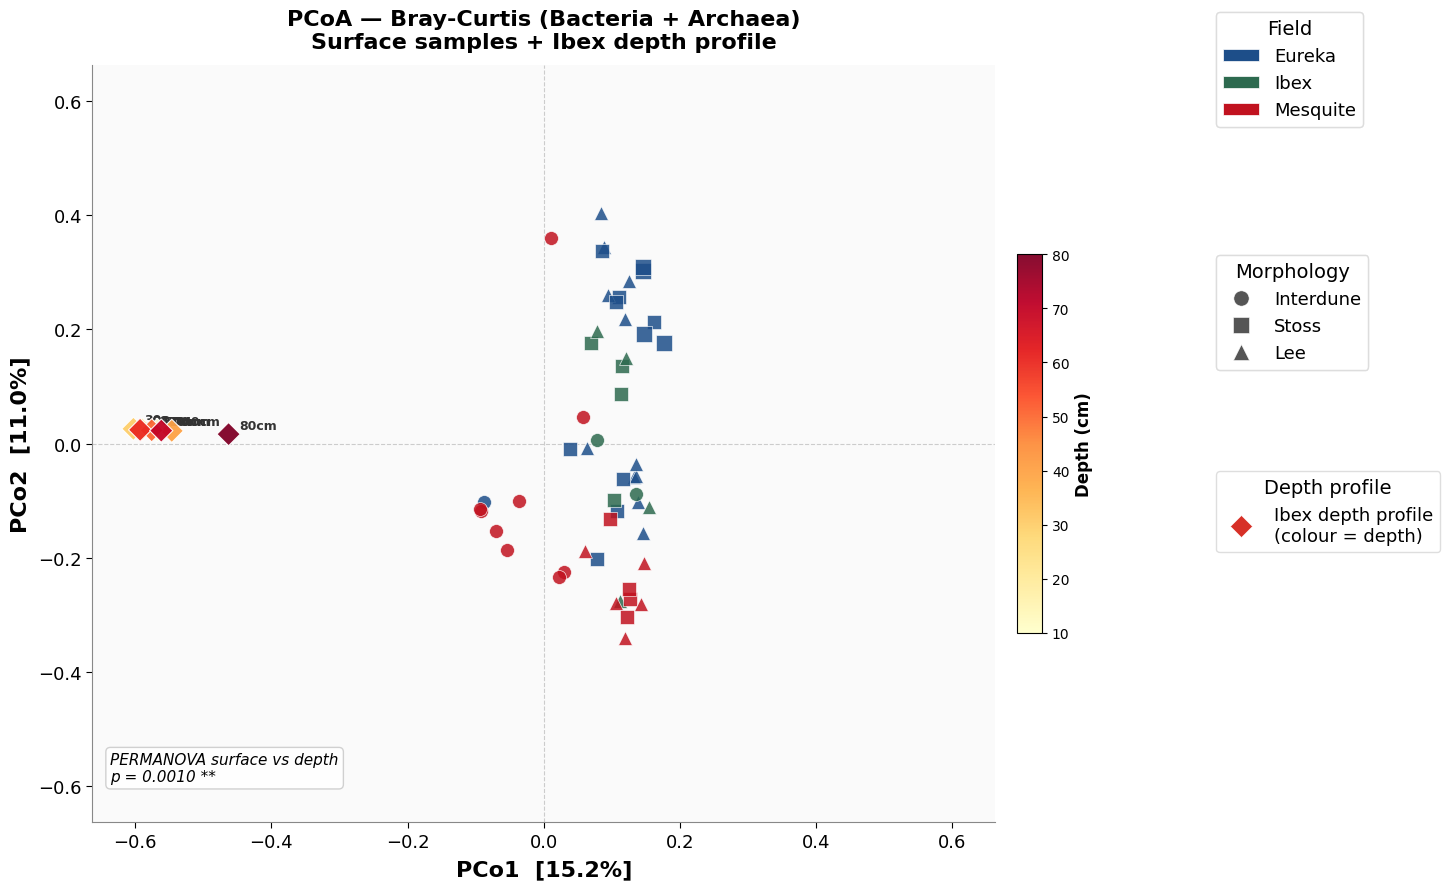

Saved: pcoa_surface_plus_depth.png


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.spatial.distance import pdist, squareform
from skbio import DistanceMatrix
from skbio.stats.distance import permanova, permdisp
import warnings
warnings.filterwarnings("ignore")
np.random.seed(42)

# ============================
# LOAD SURFACE OTU
# ============================
def load_otu(path):
    raw = pd.read_csv(path, header=None)
    first_val = str(raw.iloc[0, 0]).strip().upper()
    if first_val == "ANATOMY":
        header_row = 1
        data_start = 2
    else:
        header_row = 0
        data_start = 1

    df = raw.iloc[data_start:].copy()
    df.columns = raw.iloc[header_row].values
    df.reset_index(drop=True, inplace=True)

    n_tax     = 7
    tax_cols  = list(df.columns[-n_tax:])
    samp_cols = [c for c in df.columns[1:]
                 if c not in tax_cols
                 and "Blank" not in str(c)]

    for col in samp_cols:
        df[col] = pd.to_numeric(df[col],
                                errors="coerce").fillna(0)

    domain_col = tax_cols[0]
    df[domain_col] = (df[domain_col].astype(str)
                      .str.strip().str.lower())
    micro = df[df[domain_col].isin(
        ["bacteria", "archaea"])].copy()

    print(f"Prokaryotic ZOTUs: {len(micro)}  "
          f"|  Samples: {len(samp_cols)}")

    return pd.DataFrame(
        micro[samp_cols].values.T,
        index=samp_cols,
        columns=micro[micro.columns[0]]
    )

otu_surf = load_otu("/content/zotutab_decontam_Final.csv")

meta = pd.read_csv("/content/PERM_metadata.csv").rename(
           columns={"Sample Name:": "SampleID"})
meta["SampleID"] = meta["SampleID"].str.strip()
meta = meta.set_index("SampleID")

shared   = sorted(set(otu_surf.index) & set(meta.index))
otu_surf = otu_surf.loc[shared]
meta_aln = meta.loc[shared].copy()
meta_aln["Morphology"] = meta_aln["Morphology"].str.strip()

print(f"Surface samples: {len(shared)}")

# ============================
# LOAD DEPTH OTU
# uses relabund depth file
# ============================
rel_depth_path = "/content/zotutab_decontam_RelAbund_Final_Depth_Only.csv"
raw_dep = pd.read_csv(rel_depth_path, header=None)

first_val_d = str(raw_dep.iloc[0, 0]).strip().upper()
if first_val_d == "ANATOMY":
    header_row_d = 1
    data_start_d = 2
else:
    header_row_d = 0
    data_start_d = 1

df_dep = raw_dep.iloc[data_start_d:].copy()
df_dep.columns = raw_dep.iloc[header_row_d].values
df_dep.reset_index(drop=True, inplace=True)

tax_cols = ["Domain", "Phylum", "Class", "Order",
            "Family", "Genus", "Species"]
zotu_col_d = df_dep.columns[0]

sample_cols_d = [c for c in df_dep.columns
                 if c not in tax_cols
                 and c != zotu_col_d
                 and "Blank" not in str(c)]

df_dep[sample_cols_d] = df_dep[sample_cols_d].apply(
    pd.to_numeric, errors="coerce").fillna(0)
df_dep["Domain"] = df_dep["Domain"].str.lower().str.strip()
df_dep["Phylum"] = df_dep["Phylum"].str.lower().str.strip()

micro_dep = df_dep[
    df_dep["Domain"].isin(["bacteria", "archaea"]) &
    (df_dep["Phylum"] != "bacteria") &
    df_dep["Phylum"].notna()
].copy()

depth_map = {
    "IX.10CM.A": 10, "IX.20CM.B": 20,
    "IX.30CM.A": 30, "IX.40CM.A": 40,
    "IX.50CM.A": 50, "IX.60CM.A": 60,
    "IX.70CM.A": 70, "IX.80CM.A": 80,
}

depth_samps = [s for s in sample_cols_d if s in depth_map]
depth_samps.sort(key=lambda s: depth_map[s])

otu_depth = (
    micro_dep.set_index(zotu_col_d)[depth_samps]
    .T.fillna(0)
)
otu_depth.index.name   = None
otu_depth.columns.name = None

print(f"Depth samples: {depth_samps}")
print(f"Depth OTU matrix: {otu_depth.shape}")

# ============================
# COMBINE SURFACE + DEPTH
# align columns (ZOTUs)
# ============================
all_cols      = otu_surf.columns.union(otu_depth.columns)
otu_surf_aln  = otu_surf.reindex(
    columns=all_cols, fill_value=0)
otu_depth_aln = otu_depth.reindex(
    columns=all_cols, fill_value=0)

otu_combined = pd.concat([otu_surf_aln, otu_depth_aln])
print(f"Combined matrix: {otu_combined.shape}")

# ============================
# BRAY-CURTIS ON COMBINED
# ============================
bc_comb = squareform(pdist(
    otu_combined.values.astype(float),
    metric="braycurtis"))

# ============================
# PCoA
# ============================
D2   = bc_comb ** 2
B    = -0.5 * (D2
               - D2.mean(1, keepdims=True)
               - D2.mean(0, keepdims=True)
               + D2.mean())
ev, evec = np.linalg.eigh(B)
idx  = np.argsort(ev)[::-1]
ev   = ev[idx]
evec = evec[:, idx]
pos  = ev > 0
coords_comb = evec[:, pos] * np.sqrt(ev[pos])
var_comb    = ev[pos] / ev[pos].sum() * 100

print(f"\nPCoA variance: PCo1={var_comb[0]:.1f}%  "
      f"PCo2={var_comb[1]:.1f}%")

# ============================
# PERMANOVA — surface vs depth
# ============================
n_surf  = len(shared)
n_depth = len(depth_samps)

group_labels = ["surface"] * n_surf + ["depth"] * n_depth
group_series = pd.Series(
    group_labels,
    index=list(otu_combined.index),
    name="Group")

dm_comb  = DistanceMatrix(bc_comb,
                           ids=list(otu_combined.index))
res_perm = permanova(dm_comb, group_series,
                     permutations=999)
p_perm   = res_perm["p-value"]
sig_perm = ("***" if p_perm < 0.001 else
            "**"  if p_perm < 0.01  else
            "*"   if p_perm < 0.05  else "ns")

print(f"\nPERMANOVA surface vs depth:")
print(f"  p = {p_perm:.4f}  {sig_perm}")

# ============================
# HELPER FUNCTIONS
# ============================
def get_field(s):
    if str(s).startswith("MF"): return "Mesquite"
    if str(s).startswith("ED"): return "Eureka"
    if str(s).startswith("IX") and "CM" not in str(s):
        return "Ibex"
    return "Other"

FIELD_COLORS = {
    "Eureka":   "#1d4e89",
    "Ibex":     "#2d6a4f",
    "Mesquite": "#c1121f"
}

MORPH_STYLE = {
    "Interdune":        ("o", 100),
    "Stoss":            ("s",  95),
    "Lee":              ("^", 100),
    "Stoss, Depth":     ("s",  95),
    "Stoss , Depth":    ("s",  95),
    "Interdune, Depth": ("o",  95),
    "Stoss, Star":      ("s", 140),
    "Stoss , Star":     ("s", 140),
    "Lee, Star":        ("^", 100),
    "Stoss, Crest":     ("s",  95),
}

# ============================
# FIGURE
# ============================
fig, ax = plt.subplots(figsize=(12, 9))
fig.patch.set_facecolor("white")

# ============================
# PLOT SURFACE SAMPLES
# coloured by field, shaped by morphology
# ============================
fields = [get_field(s) for s in shared]
morphs = meta_aln["Morphology"].fillna(
    "Interdune").str.strip().tolist()

for i in range(n_surf):
    fc     = FIELD_COLORS.get(fields[i], "gray")
    mk, sz = MORPH_STYLE.get(morphs[i], ("o", 100))
    ax.scatter(coords_comb[i, 0], coords_comb[i, 1],
               color=fc, marker=mk, s=sz,
               edgecolors="white", linewidths=0.5,
               alpha=0.85, zorder=3)

# ============================
# PLOT DEPTH SAMPLES
# coloured by depth using colormap
# diamond marker
# ============================
depth_vals_plot = [depth_map[s] for s in depth_samps]

sc = ax.scatter(
    coords_comb[n_surf:, 0],
    coords_comb[n_surf:, 1],
    c=depth_vals_plot,
    cmap="YlOrRd",
    marker="D", s=140,
    edgecolors="white", linewidths=0.8,
    alpha=0.95, zorder=5,
    vmin=10, vmax=80)

# label depth points
for i, (x_c, y_c, d) in enumerate(zip(
        coords_comb[n_surf:, 0],
        coords_comb[n_surf:, 1],
        depth_vals_plot)):
    ax.annotate(f"{d}cm", (x_c, y_c),
                textcoords="offset points",
                xytext=(8, 4), fontsize=9,
                color="#333333", fontweight="bold")

# colorbar for depth
cbar = fig.colorbar(sc, ax=ax, shrink=0.5,
                     pad=0.02, aspect=15)
cbar.set_label("Depth (cm)", fontsize=12,
               fontweight="bold")
cbar.ax.tick_params(labelsize=10)

# ============================
# AXES
# ============================
h = max(abs(coords_comb[:, 0]).max(),
        abs(coords_comb[:, 1]).max()) * 1.10

ax.axhline(0, color="#cccccc", lw=0.8, ls="--", zorder=1)
ax.axvline(0, color="#cccccc", lw=0.8, ls="--", zorder=1)
ax.set_xlim(-h, h)
ax.set_ylim(-h, h)
ax.set_xlabel(f"PCo1  [{var_comb[0]:.1f}%]",
              fontsize=16, fontweight="bold", labelpad=6)
ax.set_ylabel(f"PCo2  [{var_comb[1]:.1f}%]",
              fontsize=16, fontweight="bold", labelpad=6)
ax.set_title(
    "PCoA — Bray-Curtis (Bacteria + Archaea)\n"
    "Surface samples + Ibex depth profile",
    fontsize=16, fontweight="bold", pad=12)
ax.tick_params(labelsize=13, length=4, width=0.8)
ax.set_facecolor("#fafafa")
for sp_ in ["top", "right"]:
    ax.spines[sp_].set_visible(False)
for sp_ in ["bottom", "left"]:
    ax.spines[sp_].set_color("#888888")

# ============================
# PERMANOVA annotation
# ============================
ax.text(0.02, 0.05,
        f"PERMANOVA surface vs depth\n"
        f"p = {p_perm:.4f} {sig_perm}",
        transform=ax.transAxes,
        ha="left", va="bottom",
        fontsize=11, style="italic",
        bbox=dict(boxstyle="round,pad=0.3",
                  facecolor="white",
                  edgecolor="#cccccc",
                  alpha=0.9))

# ============================
# LEGENDS
# field colours + morphology symbols
# + depth profile indicator
# ============================
field_handles = [
    mpatches.Patch(facecolor=c, edgecolor="white",
                   lw=0.5, label=f)
    for f, c in FIELD_COLORS.items()
]

morph_legend_items = [
    ("Interdune", "o", 11),
    ("Stoss",     "s", 11),
    ("Lee",       "^", 11),
]
morph_handles = [
    plt.Line2D([0],[0], marker=mk, color="w",
               markerfacecolor="#555555",
               markeredgecolor="white",
               markeredgewidth=0.4,
               markersize=ms, label=mo, linewidth=0)
    for mo, mk, ms in morph_legend_items
]

depth_handle = plt.Line2D(
    [0],[0], marker="D", color="w",
    markerfacecolor="#D73027",
    markeredgecolor="white",
    markeredgewidth=0.4,
    markersize=11,
    label="Ibex depth profile\n(colour = depth)",
    linewidth=0)

leg1 = fig.legend(
    handles=field_handles,
    title="Field",
    loc="upper left",
    bbox_to_anchor=(1.01, 0.99),
    frameon=True, framealpha=0.95,
    edgecolor="#dddddd",
    fontsize=13, title_fontsize=14)

leg2 = fig.legend(
    handles=morph_handles,
    title="Morphology",
    loc="upper left",
    bbox_to_anchor=(1.01, 0.72),
    frameon=True, framealpha=0.95,
    edgecolor="#dddddd",
    fontsize=13, title_fontsize=14)

leg3 = fig.legend(
    handles=[depth_handle],
    title="Depth profile",
    loc="upper left",
    bbox_to_anchor=(1.01, 0.48),
    frameon=True, framealpha=0.95,
    edgecolor="#dddddd",
    fontsize=13, title_fontsize=14)

fig.add_artist(leg1)
fig.add_artist(leg2)

plt.tight_layout()
plt.savefig("pcoa_surface_plus_depth.png",
            dpi=300, bbox_inches="tight",
            facecolor="white")
plt.show()
print("Saved: pcoa_surface_plus_depth.png")